In [1]:
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt

# Mini-projet 6 : Atterrissage lunaire

Martin Desombre & Benoît Monnereau-Moinier

### Question 1

$$
v_y^{k+1} = v_y^k + \frac{\Delta t}{2}\left(a_y^k + a_y^{k+1}\right)
$$

$$
y^{k+1} = y^k + v_y^k\,\Delta t
+ \frac{\Delta t^2}{3} a_y^k
+ \frac{\Delta t^2}{6} a_y^{k+1}
$$

_(écriture LateX généré par IA)_

$$
J = \frac{\Delta t}{3}
\sum_{k=0}^{N-1} \Big[
(a_h^k)^2 + (a_h^{k+1})^2 + a_h^k a_h^{k+1}
+ (a_y^k)^2 + (a_y^{k+1})^2 + a_y^k a_y^{k+1}
\Big]
$$

_(écriture LateX généré par IA)_

### Question 4

In [101]:
def resolutionQ4(T, N, h0, vh0, y0, vy0, amax, grav):
    deltaT = T/N
    nb = N + 1

    ah = ca.SX.sym('ah', nb, 1)
    ay = ca.SX.sym('ay', nb, 1)
    vh = ca.SX.sym('vh', nb, 1)
    vy = ca.SX.sym('vy', nb, 1)
    h = ca.SX.sym('h', nb, 1)
    y = ca.SX.sym('y', nb, 1)

    x = ca.vertcat(ah, ay, vh, vy, h, y)
    print(x.shape)
    lbx = []
    ubx = []

    lbx += [0]*nb
    ubx += [ca.inf]*nb
    lbx += [-ca.inf]*nb
    ubx += [ca.inf]*nb
    lbx += [vh0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vh0] + [ca.inf]*(nb-2) + [0]
    lbx += [vy0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vy0] + [ca.inf]*(nb-2) + [0]
    lbx += [h0] + [0]*(nb-2) + [0]
    ubx += [h0] + [ca.inf]*(nb-2) + [0]
    lbx += [y0] + [-ca.inf]*(nb-2) + [0]
    ubx += [y0] + [ca.inf]*(nb-2) + [0]

    assert len(lbx) == len(ubx), "pb longueur lbx vs ubx"
    assert len(lbx) == x.shape[0], "pb longueur x vs bx"
    nbvar = x.shape[0]

    g = []
    lbg = []
    ubg = []

    #dynamique selon h
    for k in range(N):
        g.append(vh[k]-grav*deltaT+(ah[k]+ah[k+1])*deltaT/2-vh[k+1])
        lbg.append(0)
        ubg.append(0)

    deltaTC = deltaT**2
    for k in range(N):
        g.append(h[k]-vh[k]*deltaT-grav*deltaTC/2+deltaTC*ah[k]/3+deltaTC*ah[k+1]/6-h[k+1])
        lbg.append(0)
        ubg.append(0)

    #dynamique selon y
    for k in range(N):
        g.append(vy[k]+(ay[k]+ay[k+1])*deltaT/2 - vy[k+1])
        lbg.append(0)
        ubg.append(0)

    for k in range(N):
        g.append(y[k]+vy[k]*deltaT+ay[k]*deltaTC/3+ay[k+1]*deltaTC/6)
        lbg.append(0)
        ubg.append(0)

    #amax
    for k in range(nb):
        g.append(ah[k]**2 + ay[k]**2)
        lbg.append(0)
        ubg.append(amax**2)

    g = ca.vertcat(*g)

    #cout
    J = (deltaT/3)
    for k in range(N):
        J+=ah[k]**2+ah[k+1]**2+ah[k]*ah[k+1]+ay[k]**2+ay[k+1]**2+ay[k]*ay[k+1]
    
    nlp = {'x': x, 'f' : J, 'g' : g}
    
    solver = ca.nlpsol('s', 'ipopt', nlp)
    sol = solver(
        x0 = np.ones(nbvar),
        lbx = lbx,
        ubx = ubx,
        lbg = lbg,
        ubg = ubg,
    )
    
    X = sol['x']
    reponse = {}
    for i, nom in enumerate(['ah', 'ay', 'vh', 'vy', 'h', 'y']):
        reponse[nom] = X[i*nb:(i+1)*nb]
    
    return reponse, float(sol['f'])


In [102]:
resolutionQ4(60*20, 20, 1000, -41, -1200, 10, 3, 1.62)

(126, 1)
This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      331
Number of nonzeros in inequality constraint Jacobian.:       42
Number of nonzeros in Lagrangian Hessian.............:       82

Total number of variables............................:      118
                     variables with only lower bounds:       40
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       80
Total number of inequality constraints...............:       21
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:       21
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.4000000e+02 2.34e+03 1.26e+00  -1.0 0.00e+00    -  0.00e+00 

({'ah': DM([1.76541, 1.76225, 1.74813, 1.73694, 1.72497, 1.71321, 1.70139, 1.68959, 1.67778, 1.66597, 1.65417, 1.64236, 1.63055, 1.61875, 1.60694, 1.59513, 1.58336, 1.57139, 1.56021, 1.54608, 1.54292]),
  'ay': DM([0.510823, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645, -0.021645]),
  'vh': DM([-41, -32.3701, -24.2588, -16.9067, -10.2493, -4.304, 0.93391, 5.46318, 9.28415, 12.3967, 14.8009, 16.4967, 17.4841, 17.7632, 17.3339, 16.196, 14.3507, 11.7933, 8.54124, 4.52991, 0]),
  'vy': DM([10, 24.6753, 23.3766, 22.0779, 20.7792, 19.4805, 18.1818, 16.8831, 15.5844, 14.2857, 12.987, 11.6883, 10.3896, 9.09091, 7.79221, 6.49351, 5.19481, 3.8961, 2.5974, 1.2987, 0]),
  'h': DM([1000, 3719.85, 5909.63, 7589.07, 8806.78, 9603.63, 10022.6, 10105.9, 9896.32, 9436.19, 8768.05, 7934.42, 6977.78, 5940.64, 4865.52, 3794.89, 2771.3, 1837.13, 1

### Question 5

In [129]:
def resolutionQ5(T, N, h0, vh0, y0, vy0, amax, grav, thetamax, gammacrit):
    deltaT = T/N
    nb = N + 1

    ah = ca.SX.sym('ah', nb, 1)
    ay = ca.SX.sym('ay', nb, 1)
    vh = ca.SX.sym('vh', nb, 1)
    vy = ca.SX.sym('vy', nb, 1)
    h = ca.SX.sym('h', nb, 1)
    y = ca.SX.sym('y', nb, 1)

    x = ca.vertcat(ah, ay, vh, vy, h, y)
    print(x.shape)
    lbx = []
    ubx = []

    lbx += [0]*nb
    ubx += [ca.inf]*nb
    lbx += [-ca.inf]*nb
    ubx += [ca.inf]*nb
    lbx += [vh0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vh0] + [ca.inf]*(nb-2) + [0]
    lbx += [vy0] + [-ca.inf]*(nb-2) + [0]
    ubx += [vy0] + [ca.inf]*(nb-2) + [0]
    lbx += [h0] + [0]*(nb-2) + [0] #ajout direct de la contrainte physique h>=0
    ubx += [h0] + [ca.inf]*(nb-2) + [0]
    lbx += [y0] + [-ca.inf]*(nb-2) + [0]
    ubx += [y0] + [ca.inf]*(nb-2) + [0]

    assert len(lbx) == len(ubx), "pb longueur lbx vs ubx"
    assert len(lbx) == x.shape[0], "pb longueur x vs bx"
    nbvar = x.shape[0]

    g = []
    lbg = []
    ubg = []

    #dynamique selon h
    for k in range(N):
        g.append(vh[k]-grav*deltaT+(ah[k]+ah[k+1])*deltaT/2-vh[k+1])
        lbg.append(0)
        ubg.append(0)

    deltaTC = deltaT**2
    for k in range(N):
        g.append(h[k]-vh[k]*deltaT-grav*deltaTC/2+deltaTC*ah[k]/3+deltaTC*ah[k+1]/6-h[k+1])
        lbg.append(0)
        ubg.append(0)

    #dynamique selon y
    for k in range(N):
        g.append(vy[k]+(ay[k]+ay[k+1])*deltaT/2 - vy[k+1])
        lbg.append(0)
        ubg.append(0)

    for k in range(N):
        g.append(y[k]+vy[k]*deltaT+ay[k]*deltaTC/3+ay[k+1]*deltaTC/6)
        lbg.append(0)
        ubg.append(0)

    #amax
    for k in range(nb):
        g.append(ah[k]**2 + ay[k]**2)
        lbg.append(0)
        ubg.append(amax**2)

    #Question 5
    tangammacrit = np.tan(gammacrit*np.pi/180)
    for k in range(nb):
        g.append(y[k]**2 - (h[k]*tangammacrit)**2)
        lbg.append(-ca.inf)
        ubg.append(0)
    
    tanthetamax = np.tan(thetamax*np.pi/180)
    for k in range(nb):
        g.append(ay[k]**2 - (ah[k]*tanthetamax)**2)
        lbg.append(-ca.inf)
        ubg.append(0)
    
    g = ca.vertcat(*g)

    #cout
    J = (deltaT/3)
    for k in range(N):
        J+=ah[k]**2+ah[k+1]**2+ah[k]*ah[k+1]+ay[k]**2+ay[k+1]**2+ay[k]*ay[k+1]
    
    nlp = {'x': x, 'f' : J, 'g' : g}
    
    solver = ca.nlpsol('s', 'ipopt', nlp)
    sol = solver(
        x0 = np.ones(nbvar),
        lbx = lbx,
        ubx = ubx,
        lbg = lbg,
        ubg = ubg,
    )
    X = sol['x']
    reponse = {}
    for i, nom in enumerate(['ah', 'ay', 'vh', 'vy', 'h', 'y']):
        print(str(i) + " : " + nom)
        reponse[nom] = X[i*nb:(i+1)*nb]
    
    '''reponse['ahF'] = X[nb:nb*2].full()
    reponse['ahTL'] = X[nb:nb*2].full().tolist()'''
    
    return reponse, float(sol['f'])


In [130]:
#resolutionQ5(60*10, 20, 1000, -41, -1200, 10, 3, 1.62, 30, 70)

In [131]:
reponse, J = resolutionQ5(60*10, 20, 1000, -41, -1200, 10, 3, 1.62, 30, 70)

(126, 1)
This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      331
Number of nonzeros in inequality constraint Jacobian.:      122
Number of nonzeros in Lagrangian Hessian.............:      120

Total number of variables............................:      118
                     variables with only lower bounds:       40
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       80
Total number of inequality constraints...............:       63
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:       21
        inequality constraints with only upper bounds:       42

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.3000000e+02 1.95e+03 1.13e+00  -1.0 0.00e+00    -  0.00e+00 

In [132]:
'''reponse['ahF'].flatten()
np.squeeze(reponse['ahF'])'''

"reponse['ahF'].flatten()\nnp.squeeze(reponse['ahF'])"

### Question 6

In [133]:
import matplotlib.gridspec as gridspec #je suis allé personnelement chercher cette bibliothèque pour améliorer le rendu, je l'ai découverte sur https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html

In [134]:
def tracés(T, N, h0, vh0, y0, vy0, amax, etha, m, grav, thetamax, gammacrit):
    deltaT = T/N
    temps = [i*deltaT for i in range(N+1)]
    #reponse, J = resolutionQ5(T, N, h0, vh0, y0, vy0, amax, grav, thetamax, gammacrit)
    tanthetamax = np.tan(thetamax)
    tangammacrit = np.tan(gammacrit)
    
    fig, axs = plt.subplots(3, 3)
    axs[0,0].plot(temps, reponse['ah'], color= "b", label="ah(t)")
    axs[0,0].plot(temps, [0 for i in range(N+1)], "--", color="b", label="ah min")

    axs[0,1].plot(temps, reponse['ay'], color = "y", label="ay(t)")
    
    axs[0,2].plot(temps, reponse['ay']**2+reponse['ah']**2, color = "r", label="ay^2(t) + ah^2(t)")
    axs[0,2].plot(temps, [amax**2 for i in range(N+1)], "+", color = "r", label="amax^2")
    
    for i in [0,1,2]:
        axs[0,i].set_ylabel("m/s²")
        axs[0,i].set_xlabel("temps (s)")
    
    axs[1,0].plot(reponse['ay'], reponse['ah'], label="ah(ay)")
    axs[1,0].plot(reponse['ay'], reponse['ah']/tanthetamax, label="attitude max")
    axs[1,0].set_ylabel("m/s²")
    axs[1,0].set_xlabel("ay (m/s²)")

    '''
    axs[1,0].plot(reponse['y'], reponse['h'], label="h(y)")
    axs[1,0].plot(reponse['y'], reponse['y']/tangammacrit, label="Cône d'aterissage")
    axs[1,0].set_ylabel("m")
    axs[1,0].set_xlabel("y (m)")
    axs[1,0].legend()
    axs[1,1].plot(temps, np.sqrt(reponse['ah']**2+reponse['ay']**2)*m/etha, label="q(t)")
    #par la contrainte h >= 0 on a nessessairement theta dans -pi/2:pi/2 d'où l'usage d'arctangente:
    axs[1,1].plot(temps, np.arctan(reponse['ay']/reponse['ah']), label="theta(t)")
    axs[1,1].set_xlabel("temps (s)")
    axs[1,1].legend()
    #courbes supplémentaires
    axs[2,0].plot(temps, reponse['h'], label="h(t)")
    axs[2,0].set_ylabel("m")
    axs[2,0].set_xlabel("temps (s)")
    axs[2,0].legend()
    axs[2,1].plot(temps, reponse['y'], label="y(t)")
    axs[2,1].set_ylabel("m")
    axs[2,1].set_xlabel("temps (s)")
'''
    for i in [0,1,2]: #oui c'est une abbération de faire comme ça mais numby ralait
        for j in [0,1,2]:
            axs[i,j].legend()

    plt.tight_layout()
    plt.show()

C:\Users\Benoi\AppData\Local\Temp\ipykernel_12308\3793827845.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i,j].legend()


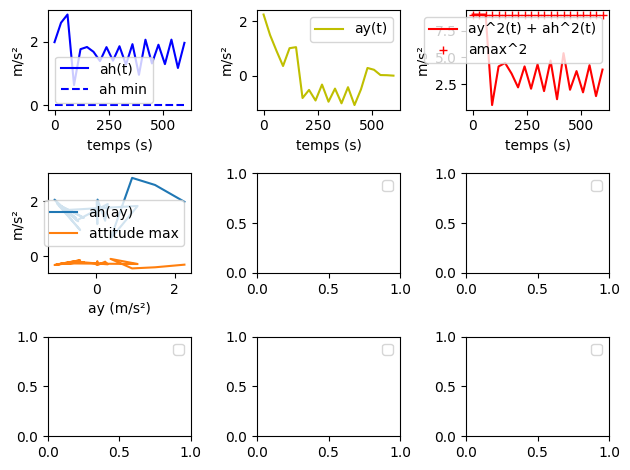

In [135]:
tracés(60*10, 20, 1000, -41, -1200, 10, 3,3050, 15000, 1.62, 30, 70)

In [136]:
def tracés2(T, N, h0, vh0, y0, vy0, amax, etha, m, grav, thetamax, gammacrit):
    deltaT = T/N
    temps = [i*deltaT for i in range(N+1)]
    #reponse, J = resolutionQ5(T, N, h0, vh0, y0, vy0, amax, grav, thetamax, gammacrit)
    tanthetamax = np.tan(thetamax)
    tangammacrit = np.tan(gammacrit)
    
    fig = plt.figure(figsize=(8,8))
    gs = fig.add_gridspec(4, 3)
    ax1 = fig.add_subplot(gs[0,0])
    ax1.plot(temps, reponse['ah'], color= "b", label="ah(t)")
    ax1.plot(temps, [0 for i in range(N+1)], "--", color="b", label="ah min")

    ax2 = fig.add_subplot(gs[0,1])
    ax2.plot(temps, reponse['ay'], color = "y", label="ay(t)")
    
    ax3 = fig.add_subplot(gs[0,2])
    ax3.plot(temps, reponse['ay']**2+reponse['ah']**2, color = "r", label="ay^2(t) + ah^2(t)")
    ax3.plot(temps, [amax**2 for i in range(N+1)], "+", color = "r", label="amax^2")
    
    for ax in [ax1, ax2, ax3]:
        ax.set_ylabel("m/s²")
        ax.set_xlabel("temps (s)")
    
    ax4 = fig.add_subplot(gs[1,:])
    ax4.plot(reponse['ay'], reponse['ah'], label="ah(ay)")
    arrayAY = np.squeeze(reponse['ay'].full()) #parceque casadi n'est pas itérable et que le rendu en array avait une dimension en trop
    ax4.scatter(arrayAY, np.abs(arrayAY)/tanthetamax, label="attitude max") #avant il fallait utiliser ca.fabs(reponse['ay'])
    ax4.set_ylabel("m/s²")
    ax4.set_xlabel("ay (m/s²)")

    ax5 = fig.add_subplot(gs[2,:])
    ax5.plot(reponse['y'], reponse['h'], label="h(y)")
    ax5.plot(reponse['y'], ca.fabs(reponse['y'])/tangammacrit, label="Cône d'aterissage")
    ax5.set_ylabel("m")
    ax5.set_xlabel("y (m)")
    '''
    axs[1,1].plot(temps, np.sqrt(reponse['ah']**2+reponse['ay']**2)*m/etha, label="q(t)")
    #par la contrainte h >= 0 on a nessessairement theta dans -pi/2:pi/2 d'où l'usage d'arctangente:
    axs[1,1].plot(temps, np.arctan(reponse['ay']/reponse['ah']), label="theta(t)")
    axs[1,1].set_xlabel("temps (s)")
    axs[1,1].legend()
    #courbes supplémentaires
    axs[2,0].plot(temps, reponse['h'], label="h(t)")
    axs[2,0].set_ylabel("m")
    axs[2,0].set_xlabel("temps (s)")
    axs[2,0].legend()
    axs[2,1].plot(temps, reponse['y'], label="y(t)")
    axs[2,1].set_ylabel("m")
    axs[2,1].set_xlabel("temps (s)")
'''
    for ax in [ax1, ax2, ax3, ax4, ax5]: 
        for j in [0,1,2]:
            ax.legend()

    plt.tight_layout()
    plt.show()

In [137]:
L = [1,2,3]

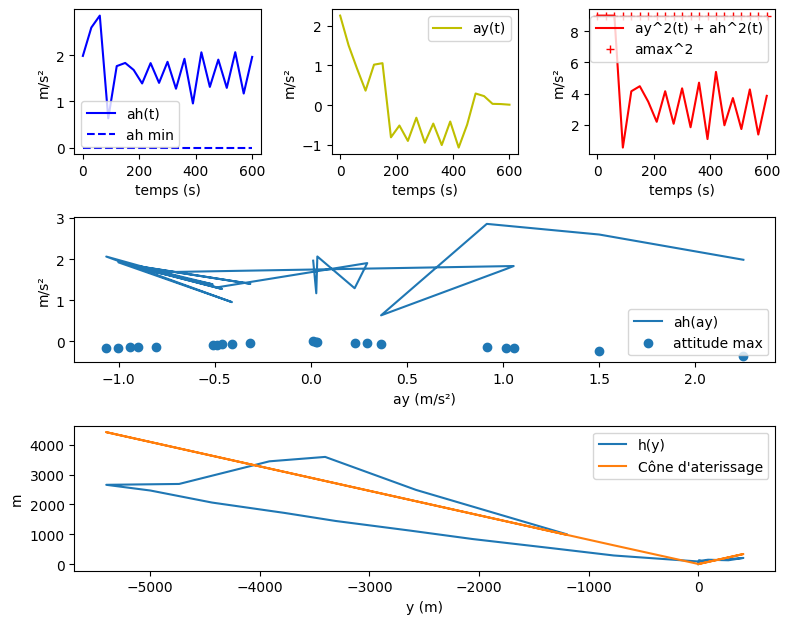

In [138]:
tracés2(60*10, 20, 1000, -41, -1200, 10, 3,3050, 15000, 1.62, 30, 70)

In [87]:
np.cos(np.pi)

np.float64(-1.0)